In [42]:
import rdkit
from rdkit import Chem
import matplotlib.pyplot as plt
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd

In [43]:
df_merged = pd.read_csv('covalent_noncovalent_MorganFP_bits_dataset.csv')
df_merged_base = df_merged[(df_merged['source'] == 'open_database') & (df_merged['cov_label'] == 0)]
df_merged_base = df_merged_base.iloc[:,:3]
df_merged_base['mol'] = df_merged_base['smiles'].apply(lambda x: Chem.MolFromSmiles(x))

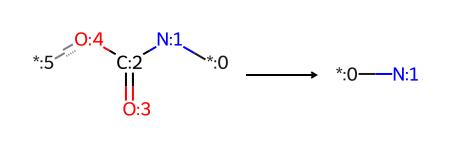

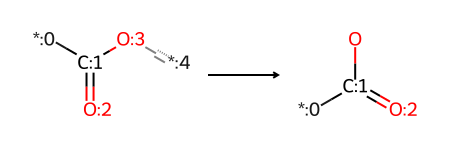

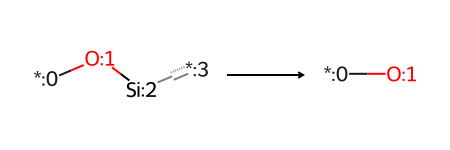

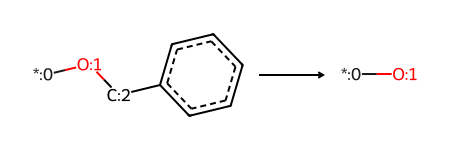

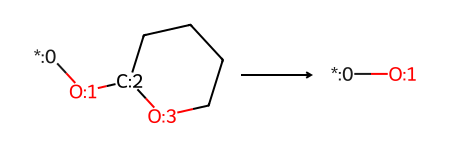

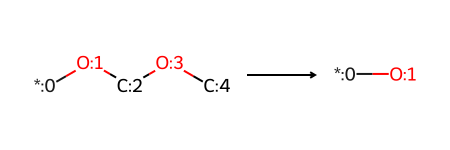

In [44]:
DEPROTECTION_RULES = {
    'Amine-from-carbamate': '[*:5][O:4]-[C:2](=[O:3])-[N:1]-[*:0]>>[N:1]-[*:0]',
    'Ester-hydrolysis': '[*:0]-[C:1](=[O:2])-[O:3][*:4]>>[*:0]-[C:1](=[O:2])-[O;H1]',
    'Hydroxyl-desilylation': '[*:0]-[O:1]-[Si:2][*:3]>>[*:0]-[O;H1:1]',
    'Hydroxyl-debenzylation': '[*:0]-[O:1]-[C;H2:2]-[c]:1:[c;H1]:[c;H1]:[c;H1]:[c;H1]:[c;H1]:1>>[*:0]-[O;H1:1]',
    'Hydroxyl-deprotection-from-THP': '[*:0]-[O:1]-[C;H1:2]-1-[C;H2]-[C;H2]-[C;H2]-[C;H2]-[O:3]-1>>[*:0]-[O;H1:1]',
    'Hydroxyl-deprotection-from-MOM': '[*:0]-[O:1]-[C;H2:2]-[O:3]-[C;H3:4]>>[*:0]-[O;H1:1]',
}
#
reactions = [AllChem.ReactionFromSmarts(s) for s in DEPROTECTION_RULES.values()]

for i in range(len(reactions)):
    display(reactions[i])

In [45]:
# remove all protecting groups from a molecule recursively until convergence

def remove_all_protecting_groups(mol, max_passes=10):
    """Remove all protecting groups from a molecule using predefined deprotection reactions."""
    # Work on a copy to avoid mutating caller's molecule
    current = Chem.Mol(mol)
    try:
        Chem.SanitizeMol(current)
    except Exception:
        pass
    last_smiles = Chem.MolToSmiles(current, isomericSmiles=True)

    for _ in range(max_passes):
        changed = False
        # Try each deprotection reaction; greedily accept first valid change
        for rxn in reactions:
            try:
                products_tuples = rxn.RunReactants((current,))
            except Exception:
                continue
            if not products_tuples:
                continue

            new_candidate = None
            for prod_tuple in products_tuples:
                for prod in prod_tuple:
                    try:
                        Chem.SanitizeMol(prod)
                        smi = Chem.MolToSmiles(prod, isomericSmiles=True)
                        if smi != last_smiles:
                            new_candidate = prod
                            break
                    except Exception:
                        continue
                if new_candidate:
                    break

            if new_candidate is not None:
                current = new_candidate
                last_smiles = Chem.MolToSmiles(current, isomericSmiles=True)
                changed = True
                # Continue looping; other reactions may still apply in this pass
        if not changed:
            break

    return current

In [46]:
df_merged_base['deprotected_mol'] = df_merged_base['mol'].apply(lambda x: remove_all_protecting_groups(x))

[19:11:17] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 5 4 2 3 
[19:11:17] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 3 4 
[19:11:17] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 3 
[19:11:17] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 
[19:11:17] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 3 
[19:11:17] mapped atoms in the reactants were not mapped in the products.
  unmapped numbers are: 2 3 4 
[19:11:18] non-ring atom 3 marked aromatic
[19:11:18] non-ring atom 20 marked aromatic
[19:11:18] non-ring atom 7 marked aromatic


In [47]:
df_merged_base['scaffold'] = df_merged_base['deprotected_mol'].apply(lambda x: Chem.MolFromSmiles(MurckoScaffold.MurckoScaffoldSmiles(mol=x)))

Total number of unique scaffolds: 2394
Number of scaffolds successfully substituted: 2358
Number of scaffolds not substituted: 36
Total number of substituted scaffolds: 10583


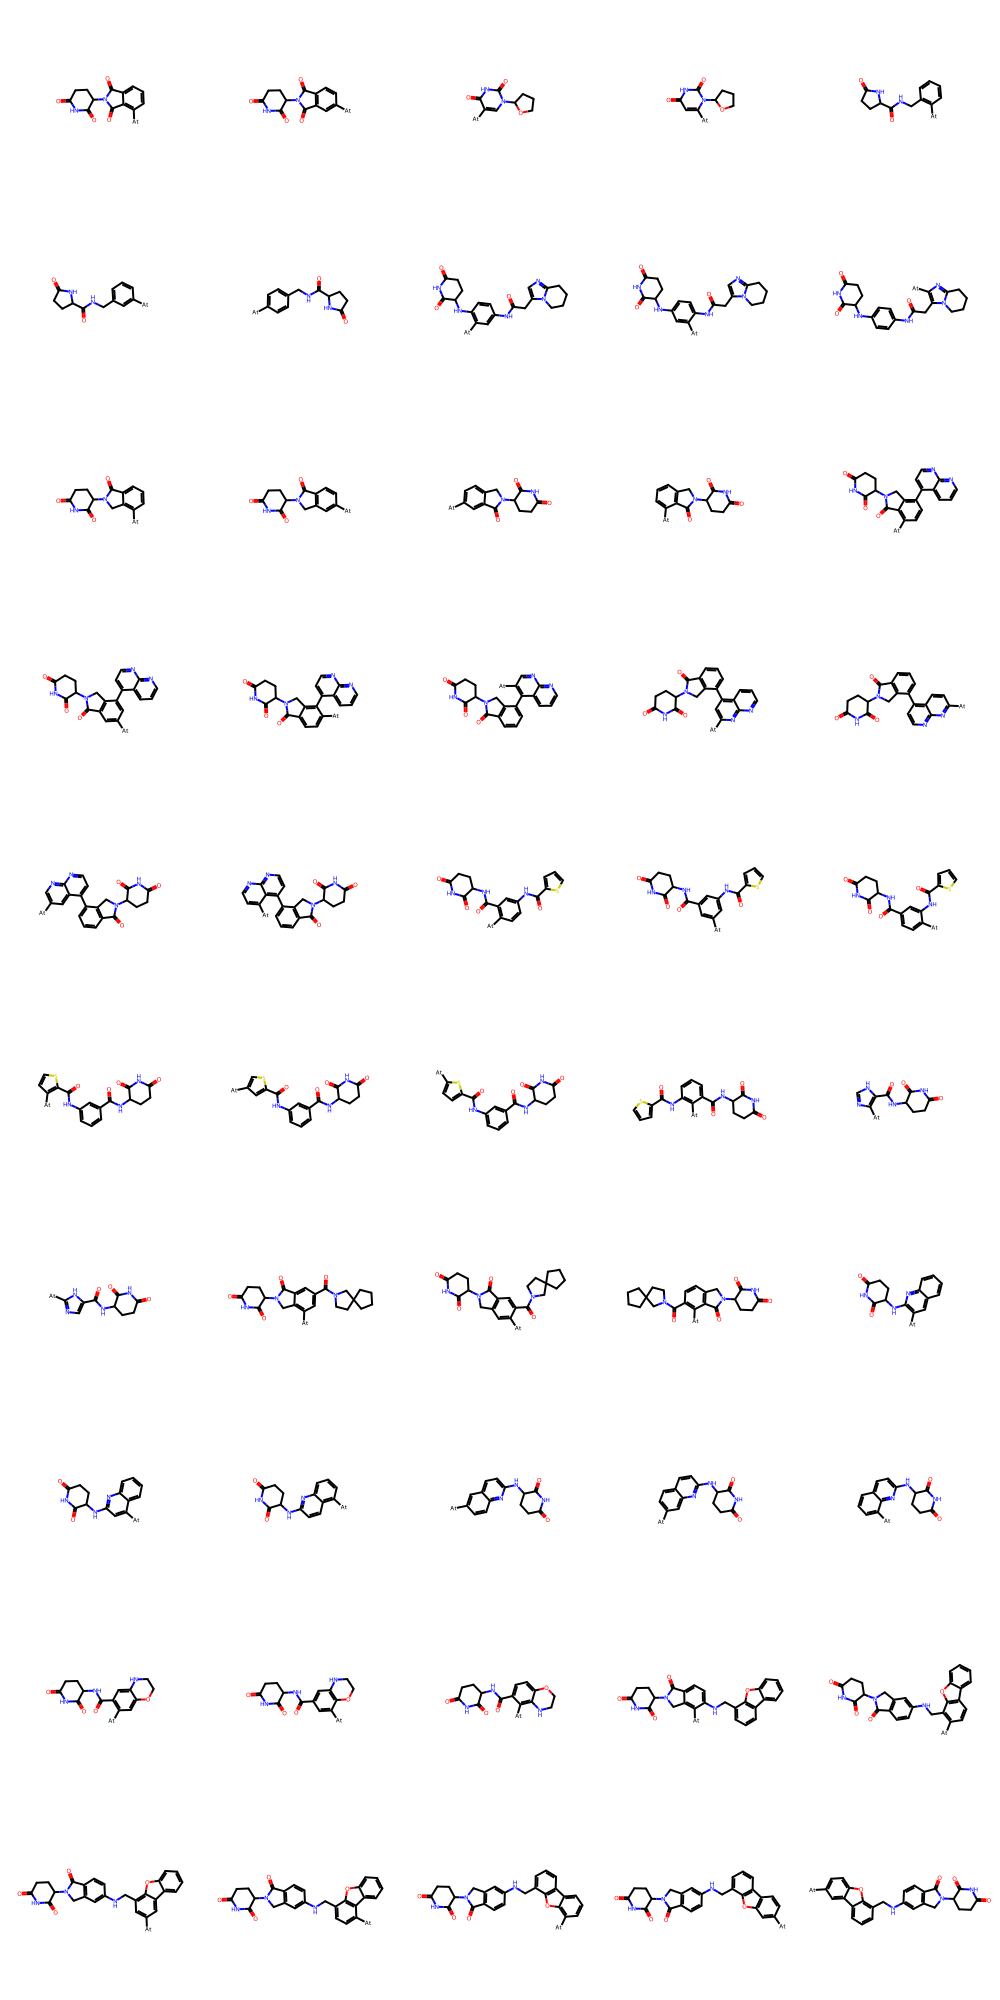

In [48]:
mols = df_merged_base['scaffold'].tolist()

#remove duplicates
unique_smiles = set()
unique_mols = []
for m in mols:
    smi = Chem.MolToSmiles(m)
    if smi not in unique_smiles:
        unique_smiles.add(smi)
        unique_mols.append(m) 

print(f'Total number of unique scaffolds: {len(unique_mols)}')

# Define Reaction to replace Hydrogen on aromatic carbon with Astatine
# [c:1][H] matches aromatic carbon (1) attached to Hydrogen
# [c:1][At] keeps the carbon and attaches Astatine
replace_h_rxn = AllChem.ReactionFromSmarts('[c:1][H]>>[c:1][At]')

substrate = []
sub_count = 0
unsub_count = 0 
for mol in unique_mols:
    try:
        # Add explicit hydrogens to allow reaction with H
        mol_h = Chem.AddHs(mol)
        
        # Run the reaction
        # RunReactants returns a tuple of tuples of products
        # For each match of the reactants, one tuple of products is generated
        products_tuples = replace_h_rxn.RunReactants((mol_h,))
        
        valid_replaced = []
        for prod_tuple in products_tuples:
            for prod in prod_tuple:
                try:
                    # Remove Hs (this will remove the other Hs, but keep At)
                    # Note: At is not H, so it stays.
                    r = Chem.RemoveHs(prod)
                    Chem.SanitizeMol(r)
                    valid_replaced.append(r)
                except:
                    pass
        
        # Deduplicate if necessary (sometimes symmetry causes duplicates)
        # Using SMILES for deduplication
        unique_smiles = set()
        unique_mols = []
        for m in valid_replaced:
            smi = Chem.MolToSmiles(m)
            if smi not in unique_smiles:
                unique_smiles.add(smi)
                unique_mols.append(m)

        if unique_mols:
            substrate.extend(unique_mols)
            sub_count += 1
        else:
            unsub_count += 1
    except Exception as e:
        # print(e) # Optional debugging
        unsub_count += 1

print(f'Number of scaffolds successfully substituted: {sub_count}')
print(f'Number of scaffolds not substituted: {unsub_count}')
print(f'Total number of substituted scaffolds: {len(substrate)}')

if len(substrate) > 0:
    display(Draw.MolsToGridImage(substrate[:50], molsPerRow=5, subImgSize=(200,200)))
else:
    print("No substrates generated.")

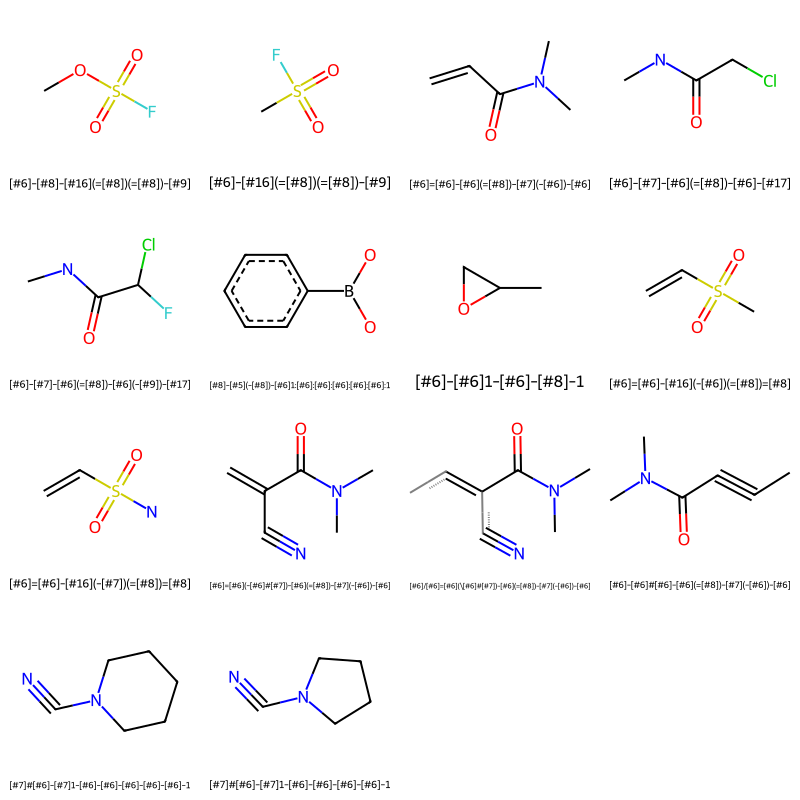

In [49]:
covalent_smiles_list = [
'COS(=O)(=O)F',
'CS(=O)(=O)F',
'C=CC(=O)N(C)C',
'CNC(=O)CCl',
'CNC(=O)C(F)Cl',
'OB(O)c1ccccc1',
'CC1CO1',
'C=CS(C)(=O)=O',
'C=CS(N)(=O)=O',
'C=C(C#N)C(=O)N(C)C',
'C/C=C(\C#N)C(=O)N(C)C',
'CC#CC(=O)N(C)C',
'N#CN1CCCCC1',
'N#CN1CCCC1'
]
smarts_mol_list = []
smarts_list = []
for i in covalent_smiles_list:
    mol = Chem.MolFromSmiles(i)
    Chem.SanitizeMol(mol)
    smarts = Chem.MolToSmarts(mol)
    smarts_list.append(smarts)
    smarts_mol = Chem.MolFromSmarts(smarts)
    smarts_mol_list.append(smarts_mol)
Draw.MolsToGridImage(smarts_mol_list, molsPerRow=4, legends=smarts_list, subImgSize=(200,200))

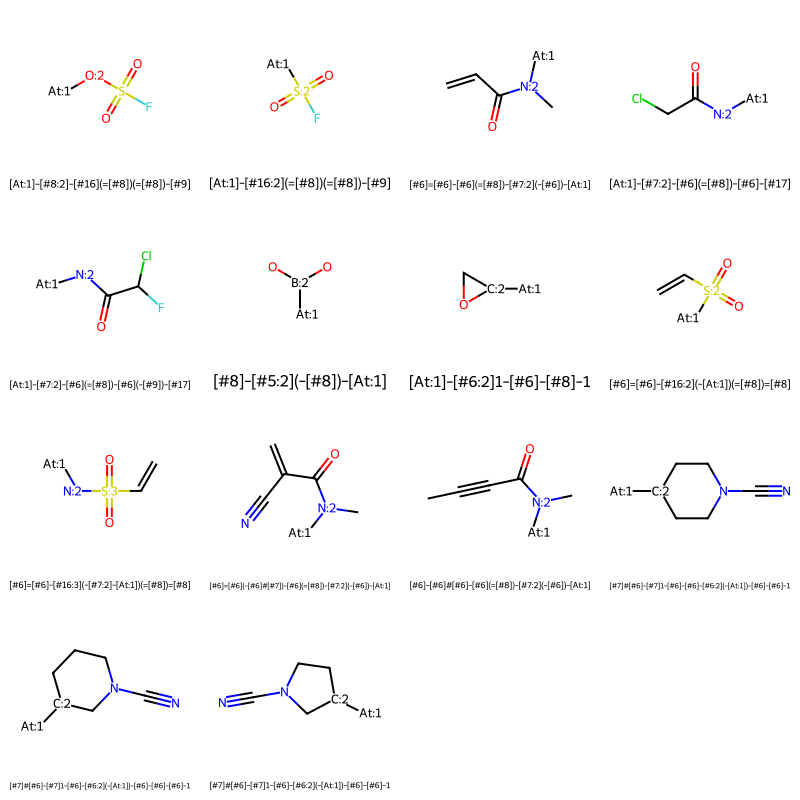

In [50]:
covalent_sub_list = [
'[At:1]-[#8:2]-[#16](=[#8])(=[#8])-[#9]',
'[At:1]-[#16:2](=[#8])(=[#8])-[#9]',
'[#6]=[#6]-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[At:1]-[#7:2]-[#6](=[#8])-[#6]-[#17]',
'[At:1]-[#7:2]-[#6](=[#8])-[#6](-[#9])-[#17]',
'[#8]-[#5:2](-[#8])-[At:1]',
'[At:1]-[#6:2]1-[#6]-[#8]-1',
'[#6]=[#6]-[#16:2](-[At:1])(=[#8])=[#8]',
'[#6]=[#6]-[#16:3](-[#7:2]-[At:1])(=[#8])=[#8]',
'[#6]=[#6](-[#6]#[#7])-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#6]-[#6]#[#6]-[#6](=[#8])-[#7:2](-[#6])-[At:1]',
'[#7]#[#6]-[#7]1-[#6]-[#6]-[#6:2](-[At:1])-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6:2](-[At:1])-[#6]-[#6]-[#6]-1',
'[#7]#[#6]-[#7]1-[#6]-[#6:2](-[At:1])-[#6]-[#6]-1'
]
warheads =[]
for i in covalent_sub_list:
    warhead = Chem.MolFromSmarts(i)
    Chem.SanitizeMol(warhead)
    warheads.append(warhead)
Draw.MolsToGridImage(warheads, molsPerRow=4, legends=covalent_sub_list, subImgSize=(200,200))

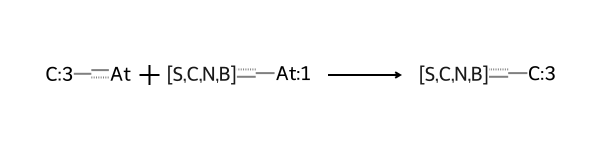

In [51]:
smarts_two_components_rxn = '[c:3][At].[At:1][S,C,N,B:2]>>[c:3][S,C,N,B:2]'
rxn = AllChem.ReactionFromSmarts(smarts_two_components_rxn)
rxn

Starting reaction with 10583 substrates and 14 warheads...
Total generated compounds: 137579


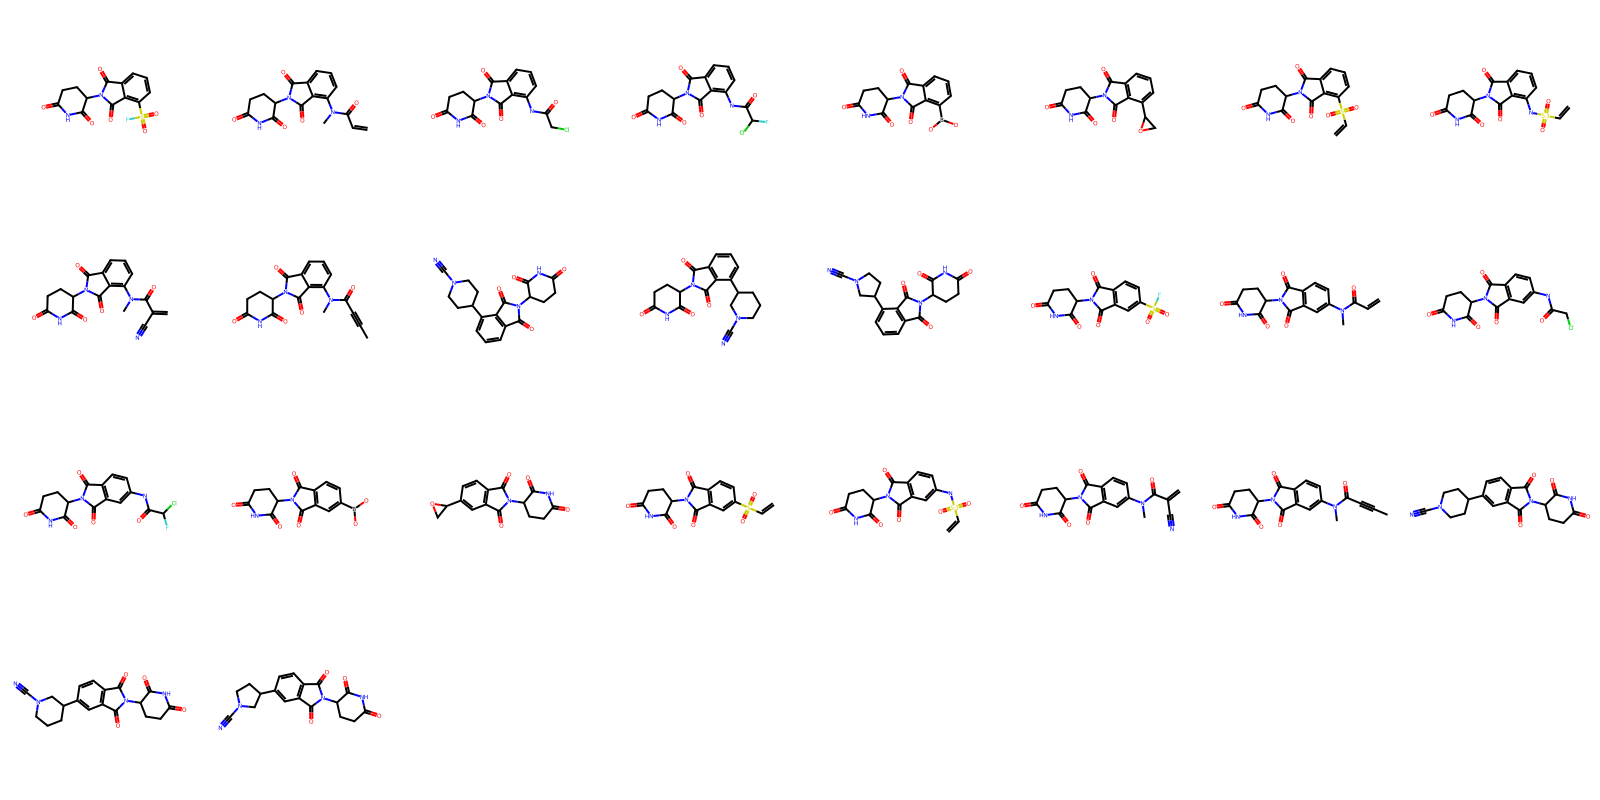

In [60]:
generated_compounds = []
print(f"Starting reaction with {len(substrate)} substrates and {len(warheads)} warheads...")

for sub_mol in substrate:
    for warhead_mol in warheads:
        try:
            products = rxn.RunReactants((sub_mol, warhead_mol))           
            for product_tuple in products:
                for prod in product_tuple:
                    try:
                        Chem.SanitizeMol(prod)
                        generated_compounds.append(prod)
                        #print('successfully generated compound')
                    except:
                        #print('failed to sanitize product')
                        continue
        except:
            #print('failed to react substrate and warhead')
            continue

print(f"Total generated compounds: {len(generated_compounds)}")
Draw.MolsToGridImage(generated_compounds[:26], molsPerRow=8, subImgSize=(200,200))

In [61]:
df_badsubstructures = pd.read_csv("unwanted_substructures.csv")
df_bad_excpet_cov = df_badsubstructures.loc[~df_badsubstructures['name'].isin(['alkyl-halide',
                                                                            'conjugated-nitrile-group',
                                                                            'cyanamide',
                                                                            'isolate-alkene',
                                                                            'Michael-acceptor',
                                                                            'phosphor-P-phthalimide',
                                                                            'triple-bond'])]

In [62]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'].isin(['heavy-metal', 'Three-membered-heterocycle', 'cyanate/aminonitrile/thiocyanate'])]

,name,smarts
27,cyanate/aminonitrile/thiocyanate,"[N,O,S]C#N"
44,heavy-metal,"[Hg,Fe,As,Sb,Zn,Se,se,Te,B,Si]"
100,Three-membered-heterocycle,"*1[O,S,N]*1"


In [63]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'Three-membered-heterocycle', 'smarts'] = '*1[S,N]*1'
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'heavy-metal', 'smarts'] = '[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]'
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'cyanate/aminonitrile/thiocyanate', 'smarts'] = '[O,S]C#N'

/tmp/ipykernel_61804/1541893138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'Three-membered-heterocycle', 'smarts'] = '*1[S,N]*1'
/tmp/ipykernel_61804/1541893138.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bad_excpet_cov.loc[df_bad_excpet_cov['name'] == 'heavy-metal', 'smarts'] = '[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]'
/tmp/ipykernel_61804/1541893138.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#return

In [64]:
df_bad_excpet_cov.loc[df_bad_excpet_cov['name'].isin(['heavy-metal', 'Three-membered-heterocycle', 'cyanate/aminonitrile/thiocyanate'])]

,name,smarts
27,cyanate/aminonitrile/thiocyanate,"[O,S]C#N"
44,heavy-metal,"[Hg,Fe,As,Sb,Zn,Se,se,Te,Si]"
100,Three-membered-heterocycle,"*1[S,N]*1"


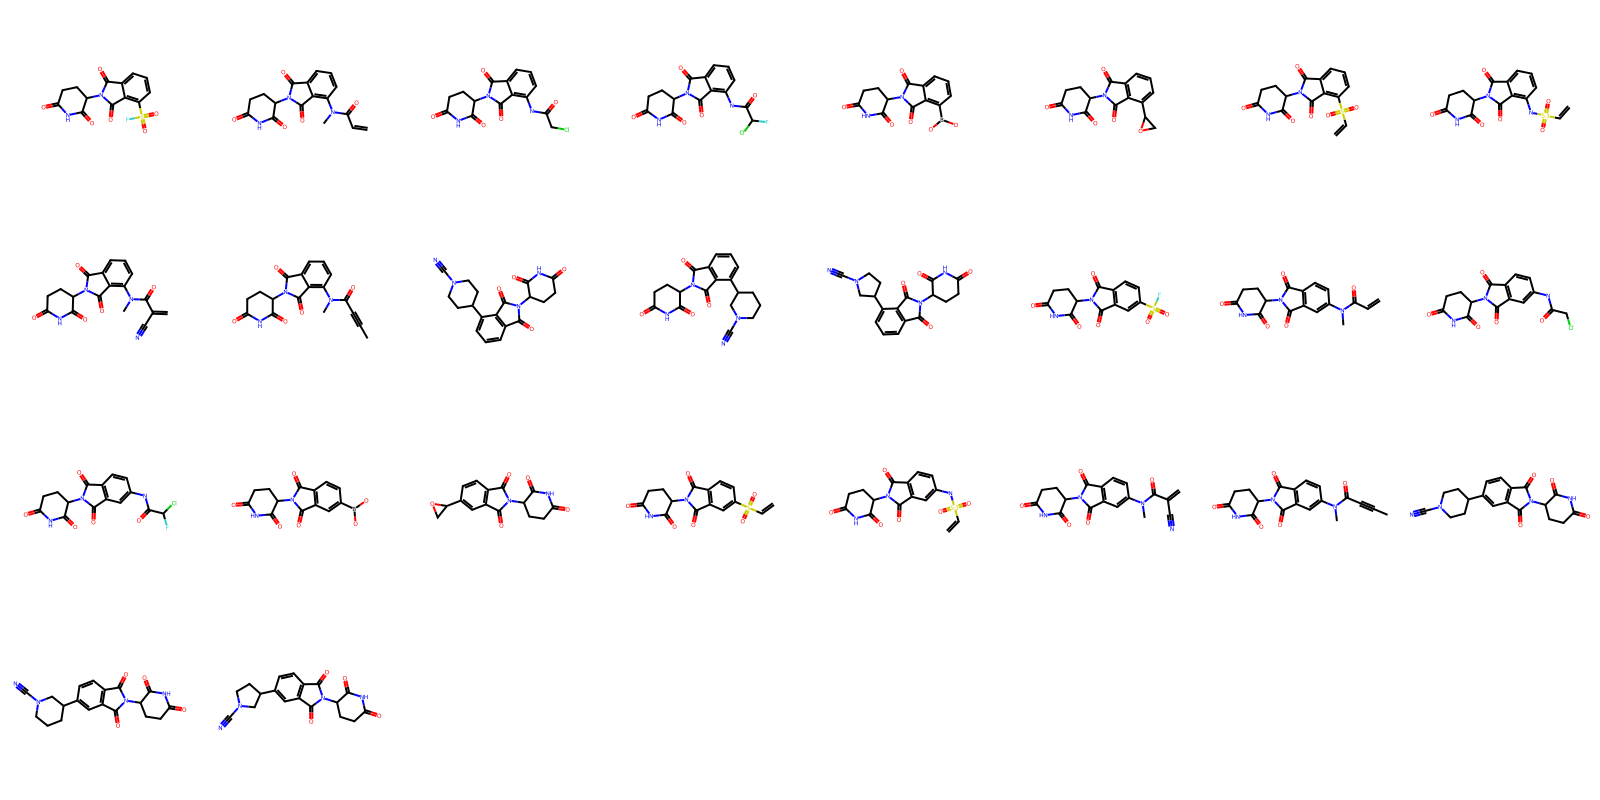

In [65]:
generated_compounds_testlist = generated_compounds[:26]
bad_dict = {}
for n, s in df_bad_excpet_cov[['name', 'smarts']].itertuples(index=False):
    bad_dict[n] = Chem.MolFromSmarts(s)

undesired = []
clean = []

for m in generated_compounds_testlist:
    match = False
    for substrate_name, substructure in bad_dict.items():
        if m.HasSubstructMatch(substructure):
            display(Draw.MolToImage(m, size=(300,300), legend=f'Matched undesired substructure: {substrate_name}'))
            undesired.append(m)
            match = True
            break
    if not match:
        clean.append(m)

Draw.MolsToGridImage(clean, molsPerRow=8, subImgSize=(200,200))

In [66]:
undesired = []
clean = []

for m in generated_compounds:
    match = False
    for substrate_name, substructure in bad_dict.items():
        if m.HasSubstructMatch(substructure):
            #display(Draw.MolToImage(m, size=(300,300), legend=f'Matched undesired substructure: {substrate_name}'))
            undesired.append(m)
            match = True
            break
    if not match:
        clean.append(m)

print(len(undesired), len(clean))

2938 134641


Number of clean compounds between 200 and 400 Da: 38157


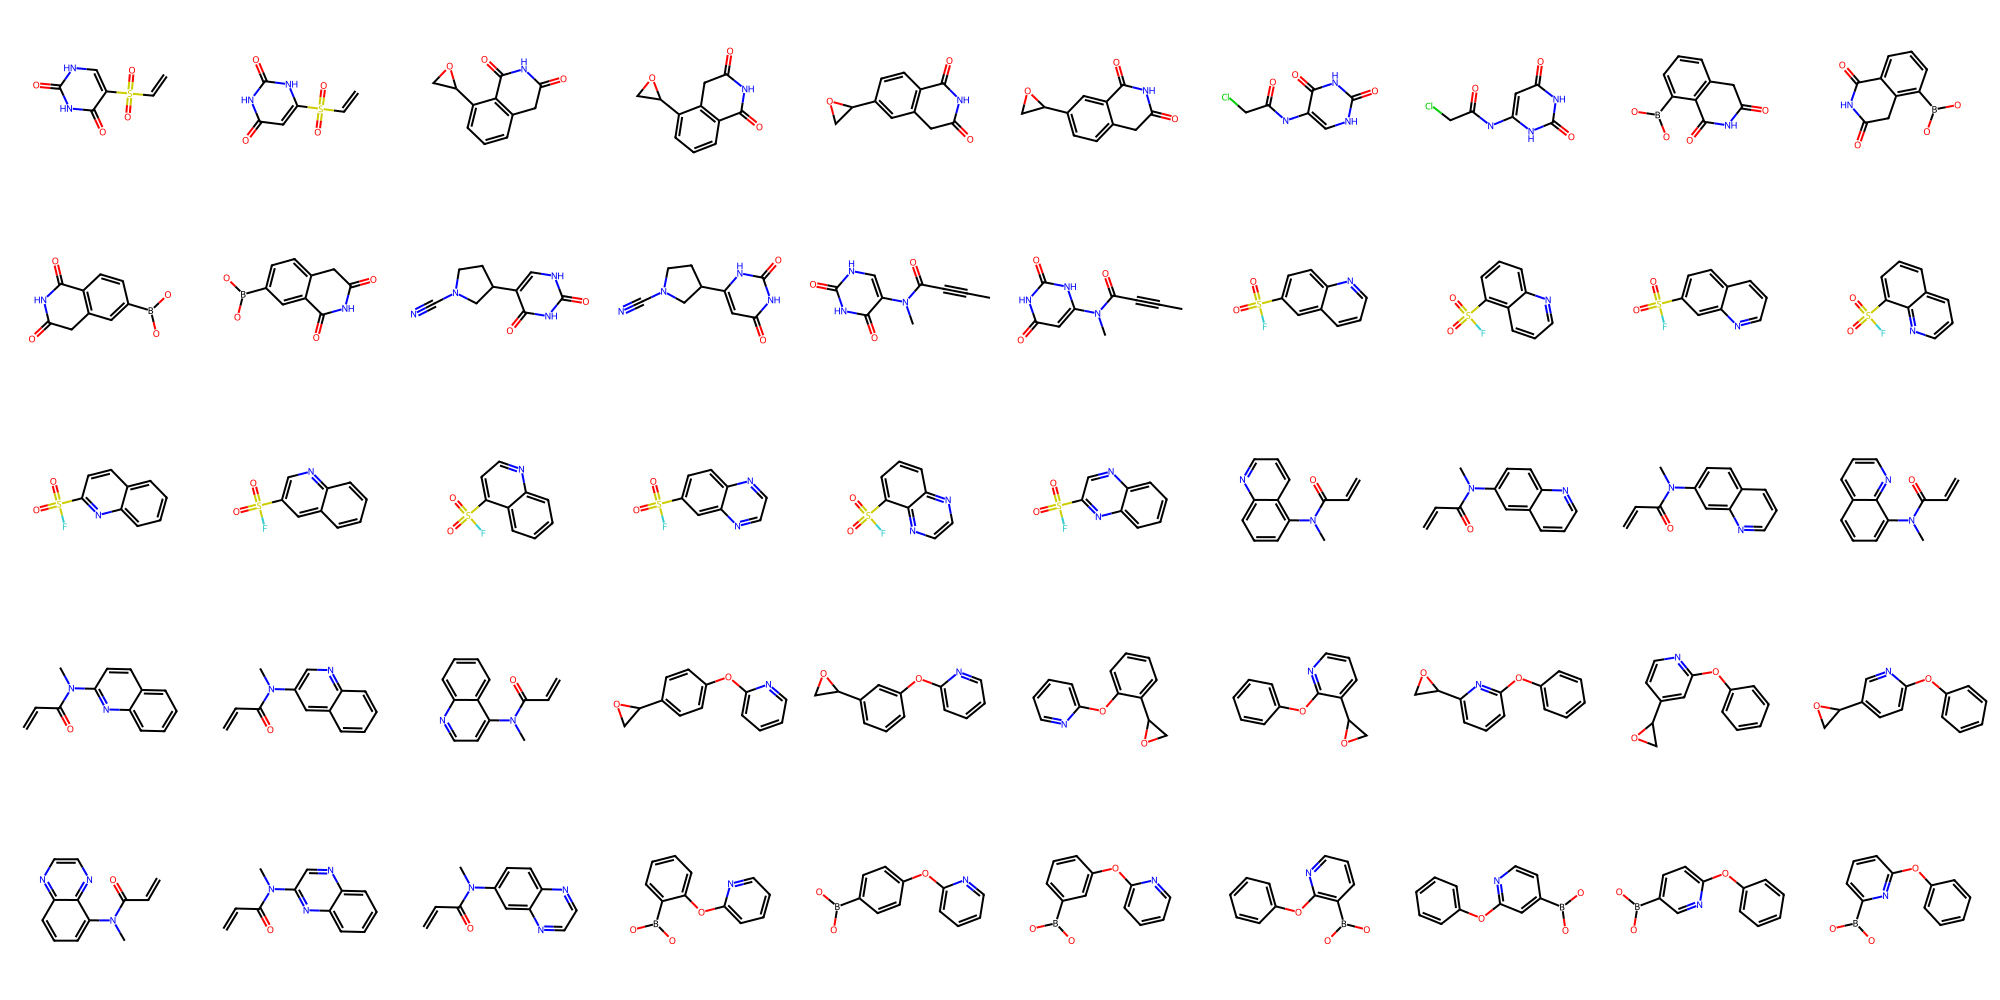

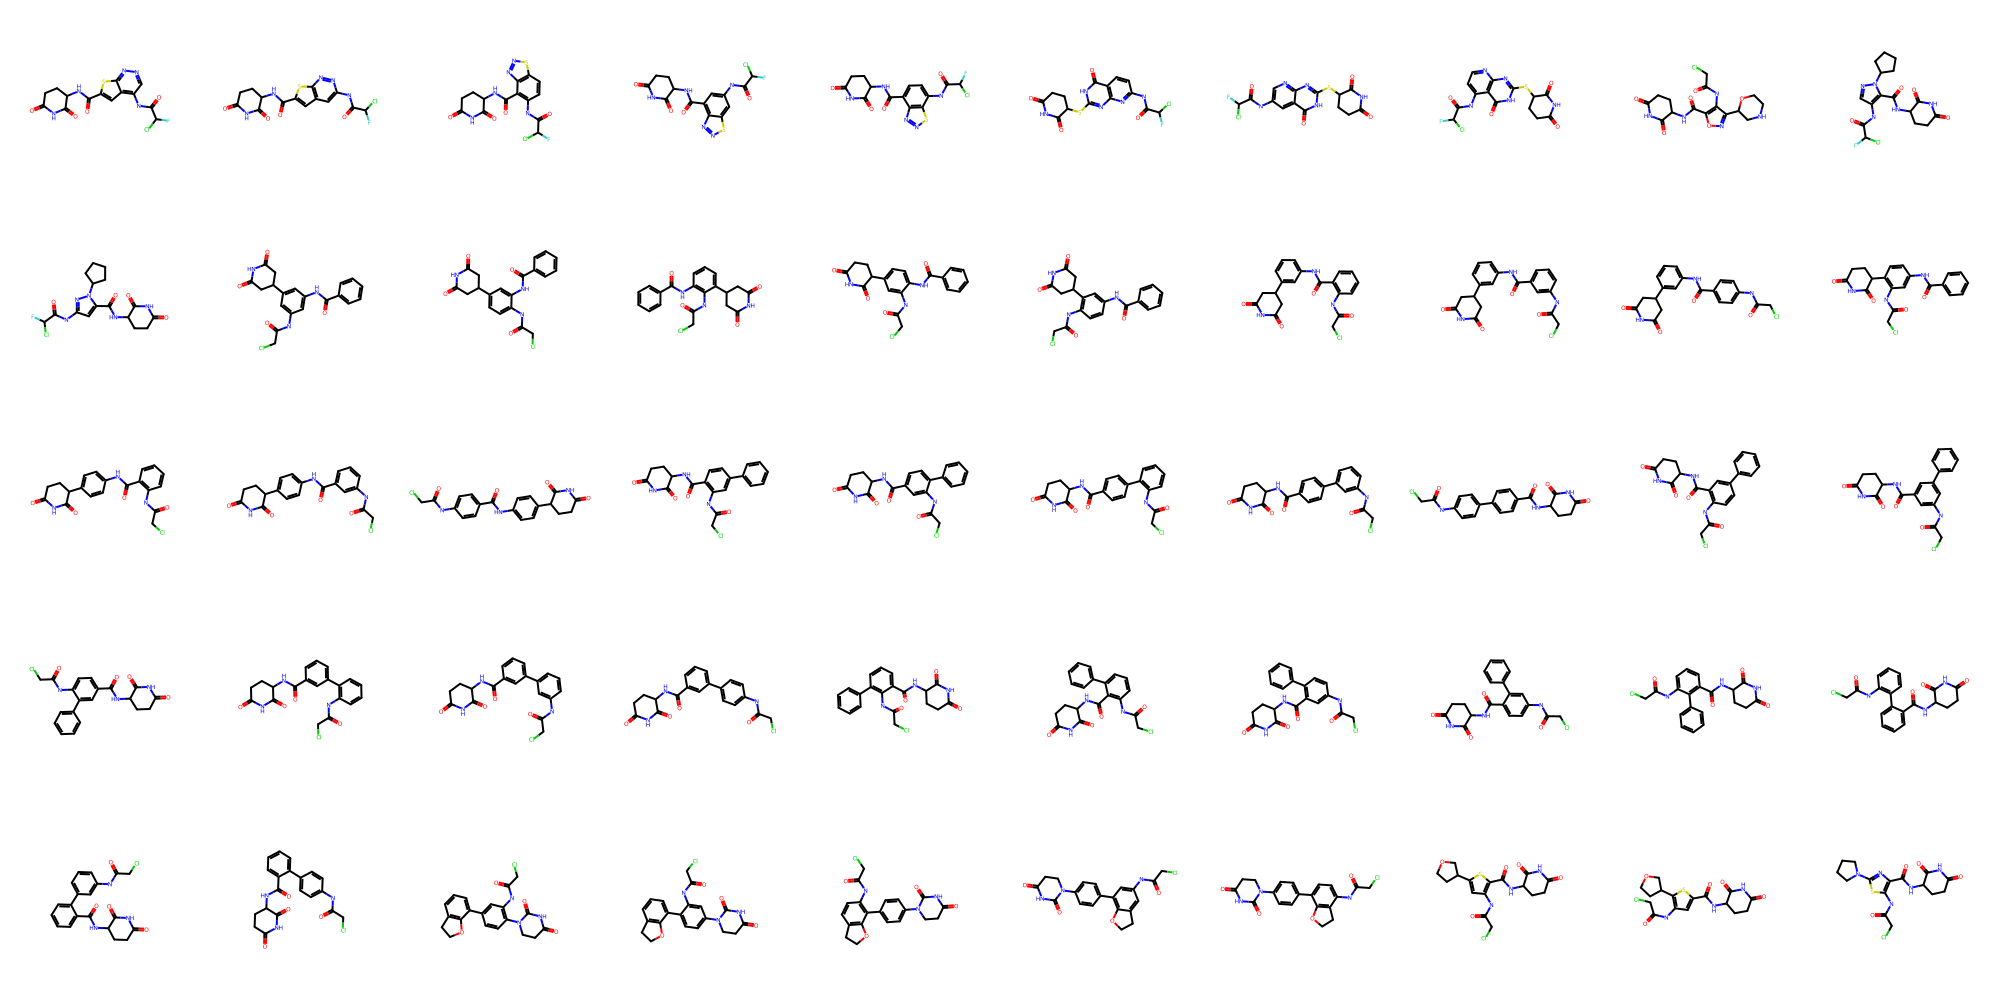

In [78]:
clean = sorted(clean, key=lambda x: Descriptors.MolWt(x), reverse=False)
clean_between_200_400 = [mol for mol in clean if 200 <= Descriptors.MolWt(mol) <= 400]
print(f'Number of clean compounds between 200 and 400 Da: {len(clean_between_200_400)}')
display(Draw.MolsToGridImage(clean_between_200_400[:50], molsPerRow=10))
display(Draw.MolsToGridImage(clean_between_200_400[-50:], molsPerRow=10))

Number of final clean compounds with imide substructure: 34481


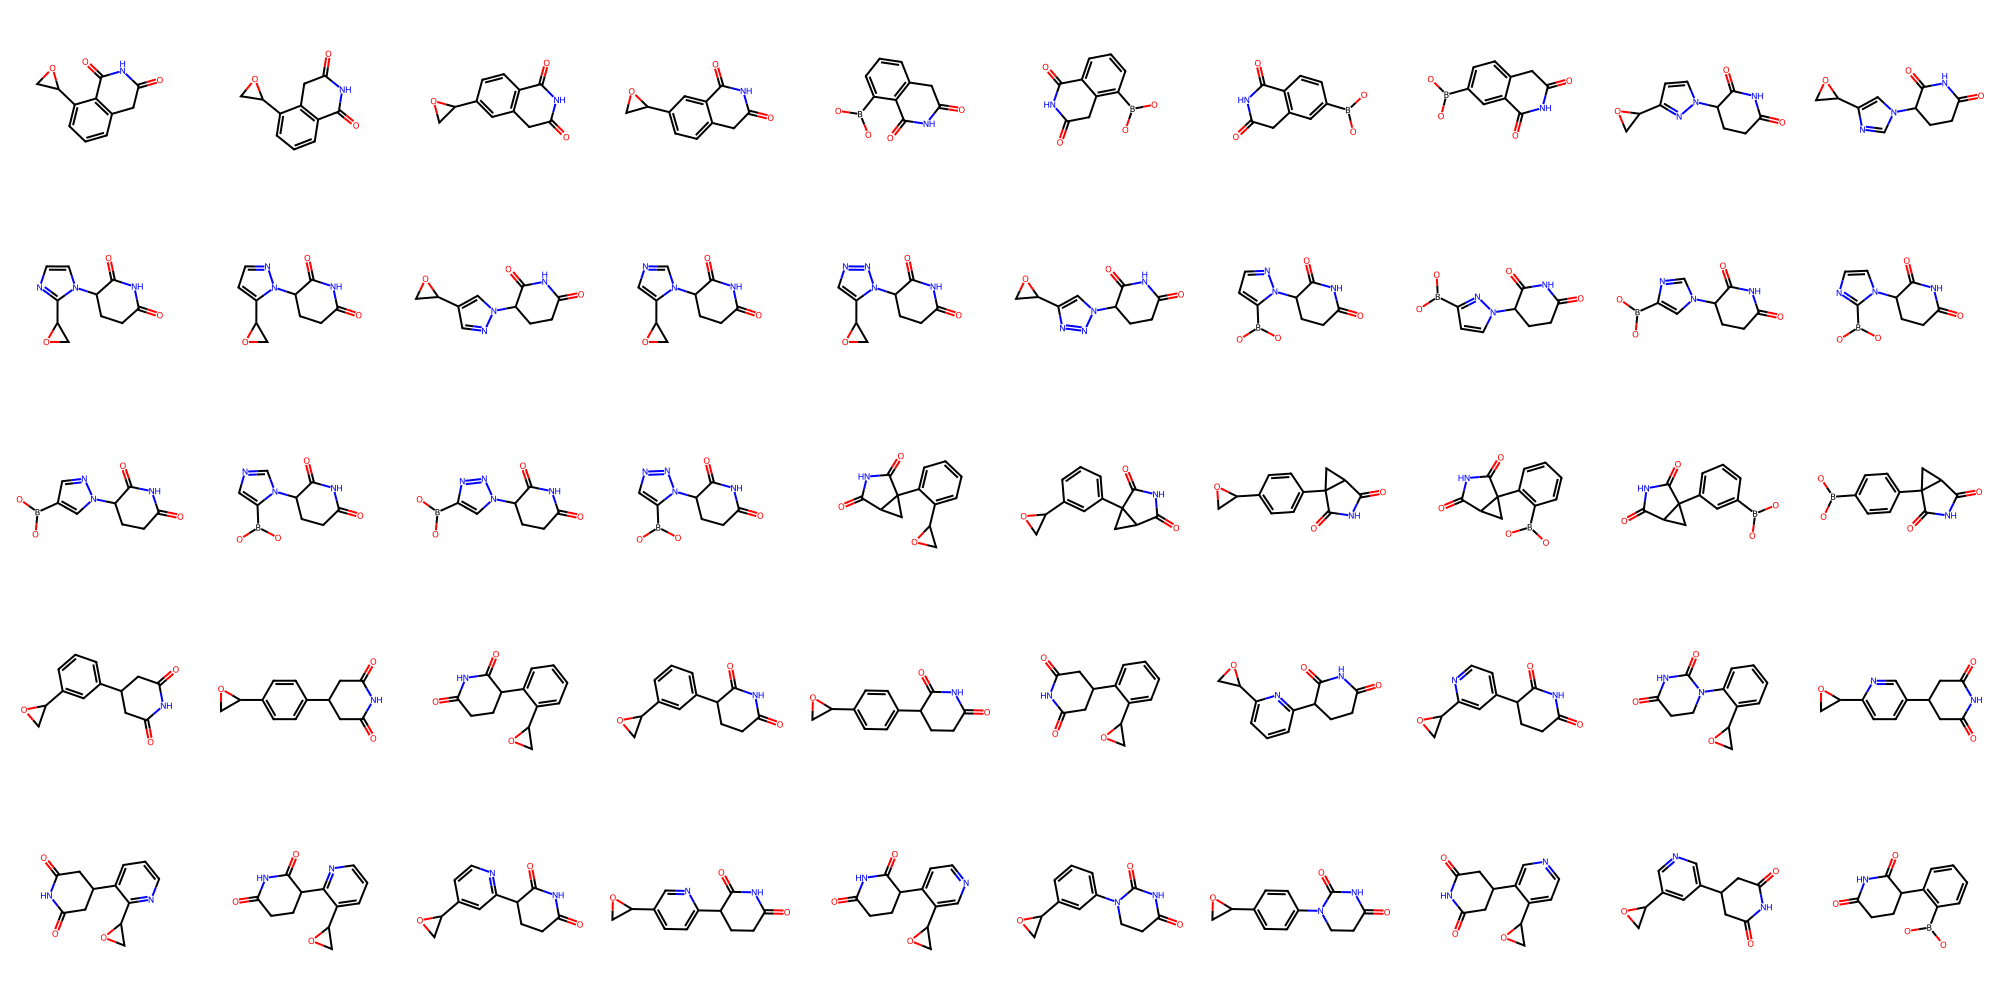

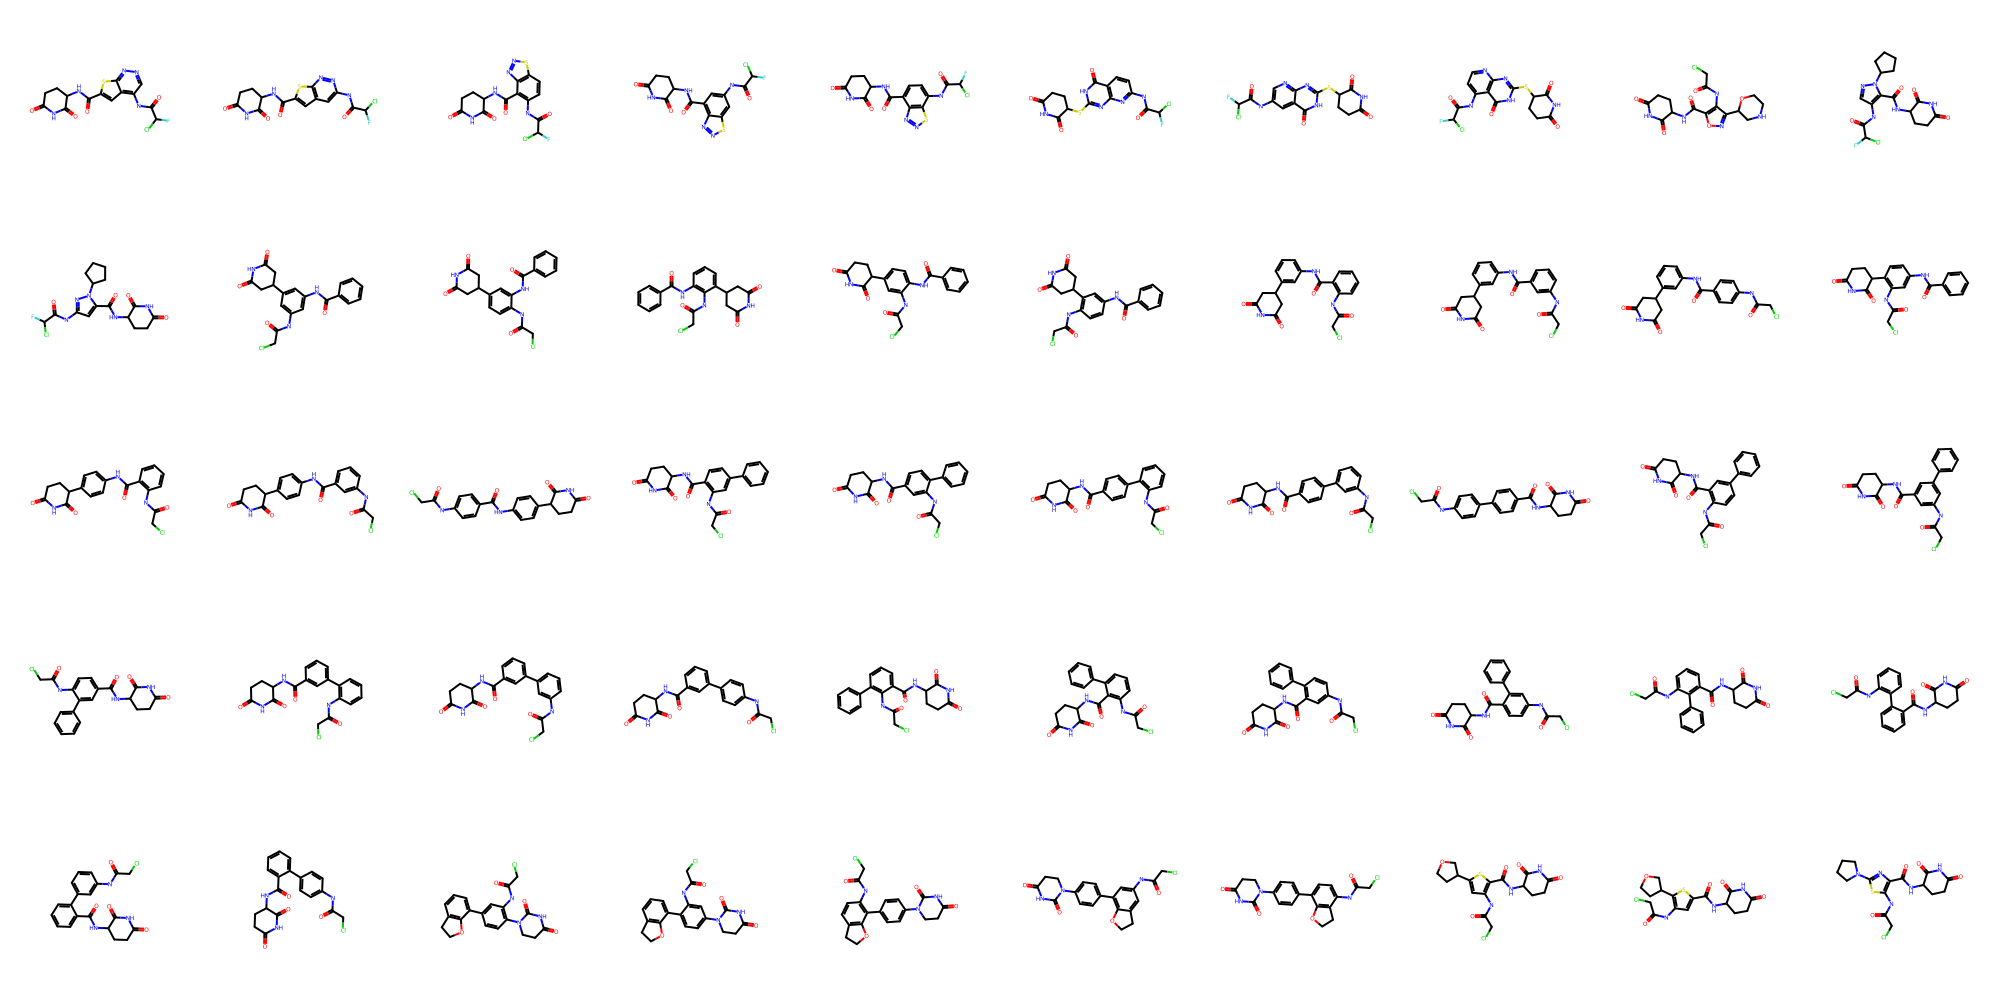

In [79]:
#check substructure imides
imide_smarts = 'C(=O)-[NH]-C(=O)'
imide_mol = Chem.MolFromSmarts(imide_smarts)
final_clean = []
for mol in clean_between_200_400:
    if mol.HasSubstructMatch(imide_mol):
        final_clean.append(mol)
print(f'Number of final clean compounds with imide substructure: {len(final_clean)}')
display(Draw.MolsToGridImage(final_clean[:50], molsPerRow=10))
display(Draw.MolsToGridImage(final_clean[-50:], molsPerRow=10))
